# Anchored Langevin on the multivariate Laplace: aiming the constant skew

Unconstrained, so there is no boundary condition and **every** constant antisymmetric $J$ leaves $\pi$
invariant — the extra flux is $J\nabla e^{-U_0}$ and $\nabla\!\cdot(J\nabla\varphi)=0$ for constant skew.
The choice of $J$ is therefore purely a *rate* choice, and the question is which one to make.

## Which multivariate Laplace?

"Multivariate Laplace" names more than one distribution, and the difference is exactly what this project
cares about — *where the potential fails to be differentiable*. Both are run below. Write
$\Sigma=LL^\top$ and $M=L^{-1}$.

| | potential $U(x)$ | non-differentiable set | exact sampling |
|---|---|---|---|
| **Target A** — elliptical Laplace | $\lVert Mx\rVert_2$ | the single point $\{0\}$ | $x=L\,r\,u$, $r\sim\mathrm{Gamma}(d,1)$, $u$ uniform on $S^{d-1}$ |
| **Target B** — correlated $\ell_1$ Laplace | $\lVert Mx\rVert_1$ | $d$ hyperplanes $\{(Mx)_i=0\}$ | $x=Ly$, $y_i\sim\mathrm{Laplace}(0,1)$ |

Target A's kink sits at a single point the chain essentially never visits — a *weak* test of
non-smoothness. Target B keeps the kinks on a set the chain crosses constantly. Neither factorises.

$\Sigma=DCD$ with $D=\mathrm{diag}(0.5,1,2)$ and $C$ equicorrelation, $\rho=0.6$.

## Dynamics

$$dX_t=-(I+J)\,\nabla U_0(X_t)\,e^{\Delta(X_t)}\,dt+\sqrt2\,e^{\Delta(X_t)/2}\,dW_t,\qquad\Delta=U-U_0,$$

with the anchor rounding off the kink. $\Delta\le0$ and bounded below, so $e^{\Delta}$ needs no clamping,
and $\nabla U$ is never evaluated.

---

## What changed

**The settings text and the code disagreed.** The prose said $\eta=5\times10^{-3}$ over 2000 iterations;
the code ran $\eta=6\times10^{-3}$ for 1500. The code is now the only source of these numbers and they are
printed below.

**Nothing had converged at the reporting horizon.** At 1500 iterations $J=0$ sits at mean $W_1=0.331$
against a floor of $0.064$ — five times above it, and still falling. It needs roughly 9000. Everything
here runs to 12000, and speed is reported as $\tau$, the iteration after which $W_1$ stays below twice the
floor, separately from stationary accuracy.

**Replicas and intervals.** Every number is 6 replicas with a bootstrap interval, run as one batched
ensemble.

**The skew was pointed in an arbitrary direction.** $J_a$ is tridiagonal — a fixed pattern with no
relation to $\Sigma$. Since unconstrained the axis is free, it can instead be put in the plane of the two
largest-variance eigenvectors, which is where the sampler actually crawls. That turns out to be most of
the available gain.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# -----------------------------
# Settings -- the only place these live
# -----------------------------
d        = 3
N        = 5000        # walkers per replica
REPLICAS = 6
MAXIT    = 12000       # long enough that J = 0 reaches the floor; 1500 was not
eta      = 6e-3
delta    = 0.2         # anchor smoothing
x_start  = 0.3
SEED     = 1006
TRACK    = 25
A_LIST   = [2.0, 4.0, 8.0]
TAU_MULT = 3.0         # tau threshold, as a multiple of the floor.  2x sat inside the
                       # stationary noise of the slower schemes and made tau unmeasurable.

SCALES, RHO = [0.5, 1.0, 2.0], 0.6


def make_L(dim, scales, rho):
    D = np.diag(scales)
    C = np.full((dim, dim), rho)
    np.fill_diagonal(C, 1.0)
    return np.linalg.cholesky(D @ C @ D)


L3 = make_L(d, SCALES, RHO)
SIG = L3 @ L3.T
Minv = torch.tensor(np.linalg.inv(L3))
EVAL, EVEC = np.linalg.eigh(SIG)
print("Sigma =\n", np.round(SIG, 3))
print("eigenvalues", np.round(EVAL, 3), "  condition number {:.1f}".format(EVAL[-1] / EVAL[0]))
print("\neta = {:g}, {} iterations, N = {} x {} replicas".format(eta, MAXIT, N, REPLICAS))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]
eigenvalues [0.131 0.595 4.525]   condition number 34.6

eta = 0.006, 12000 iterations, N = 5000 x 6 replicas


## The three constant skews

All are constant and antisymmetric, so all leave $\pi$ invariant; they differ only in which plane they
rotate.

* `tridiagonal` — the original $J_a$: $+a$ above the diagonal, $-a$ below. A fixed pattern, unrelated to
  $\Sigma$.
* `aligned` — rotation in the plane of the two **largest-variance** eigenvectors of $\Sigma$, the
  directions along which the reversible dynamics crawls.
* `anti-aligned` — the same construction in the plane of the two **smallest**, as a control.

Each is normalised to unit spectral norm before scaling by $a$, so $a$ means the same push for all three.

In [3]:
def J_tridiagonal(dim, a):
    J = (torch.diag(torch.ones(dim - 1), diagonal=1)
         - torch.diag(torch.ones(dim - 1), diagonal=-1))
    return a * J / torch.linalg.matrix_norm(J, ord=2)


def J_plane(u, v, a):
    """Generator of rotation in span(u, v), unit spectral norm, scaled by a."""
    A = np.outer(np.asarray(u, float), np.asarray(v, float))
    A = A - A.T
    return torch.tensor(a * A / np.linalg.norm(A, 2))


def J_aligned(a):
    return J_plane(EVEC[:, 2], EVEC[:, 1], a)       # two largest variances


def J_antialigned(a):
    return J_plane(EVEC[:, 0], EVEC[:, 1], a)       # two smallest


rows = []
for name, fn in [("tridiagonal", J_tridiagonal_a := (lambda a: J_tridiagonal(d, a))),
                 ("aligned", J_aligned), ("anti-aligned", J_antialigned)]:
    J = fn(4.0)
    rows.append({"skew": name,
                 "max |J + J^T|": "{:.1e}".format(float((J + J.T).abs().max())),
                 "||J||_2 at a=4": round(float(torch.linalg.matrix_norm(J, ord=2)), 3),
                 "rotates in": {"tridiagonal": "fixed pattern",
                                "aligned": "plane of the 2 largest variances",
                                "anti-aligned": "plane of the 2 smallest"}[name]})
pd.DataFrame(rows).set_index("skew")

,max |J + J^T|,||J||_2 at a=4,rotates in
skew,,,
tridiagonal,0.0e+00,4.0,fixed pattern
aligned,0.0e+00,4.0,plane of the 2 largest variances
anti-aligned,0.0e+00,4.0,plane of the 2 smallest


In [4]:
# -----------------------------
# Targets.  U is never differentiated; only U0 is.
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0


def sample_target(kind, size, rng):
    """Exact draws -- no rejection needed for either target."""
    if kind == "ell":
        r = rng.gamma(d, 1.0, size)
        u = rng.normal(size=(size, d))
        u /= np.linalg.norm(u, axis=1, keepdims=True)
        y = r[:, None] * u
    else:
        y = rng.laplace(0.0, 1.0, size=(size, d))
    return y @ L3.T


def w1_floor_per_coord(kind, size, rng, n_pairs=24):
    """W1 between two INDEPENDENT size-`size` draws, averaged over `n_pairs` fresh pairs.

    Averaging against one fixed reference is not enough: that estimator carries the
    particular reference's own deviation, and its spread across independent estimates is
    15-20% per coordinate -- on Target B a low draw put the tau threshold only 1.65x above
    the converged plateau, which turns tau into a last-crossing lottery.  Drawing both
    sides fresh each time removes the conditioning and brings the spread to a few percent.
    """
    out = np.zeros((n_pairs, d))
    for k in range(n_pairs):
        a, b = sample_target(kind, size, rng), sample_target(kind, size, rng)
        out[k] = [wasserstein_distance(a[:, i], b[:, i]) for i in range(d)]
    return out.mean(axis=0)


@torch.no_grad()
def run_replicas(kind, J, ref, S=REPLICAS, n_steps=MAXIT, seed=SEED, eta=eta):
    """Returns (iters, mean-over-coords W1 [S, ntrack], per-coord W1 [ntrack, d], X [S,N,d])."""
    U, U0, gU0 = build_target(kind)
    Mj = (torch.eye(d) + J).T
    torch.manual_seed(seed)
    x = torch.full((S * N, d), x_start)
    it, W, Wc = [], [], []
    for k in range(n_steps):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        x = x - eta * (g @ Mj) + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x)
        if (k + 1) % TRACK == 0:
            xn = x.numpy().reshape(S, N, d)
            per = np.array([[wasserstein_distance(ref[:, i], xn[r, :, i]) for i in range(d)]
                            for r in range(S)])
            it.append(k + 1)
            W.append(per.mean(axis=1))
            Wc.append(per.mean(axis=0))
    return np.array(it), np.array(W).T, np.array(Wc), x.numpy().reshape(S, N, d)


def tau_one(it, w, thr):
    bad = np.where(w > thr)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return float(it[j]) if j < len(it) else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
             if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def boot_speedup(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            draws.append(np.nanmean(a) / np.nanmean(b))
    return (np.nanmean(base) / np.nanmean(cur),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


def fmt_tau(t):
    return "never" if not np.isfinite(t[0]) else "{:.0f} [{:.0f}, {:.0f}]".format(*t)


def fmt_speed(sp):
    return "never reaches it" if not np.isfinite(sp[0]) else "{:.2f}x [{:.2f}, {:.2f}]".format(*sp)


def tau_is_resolvable(stat_mean, floor_mean, margin=1.5):
    """tau only means something if the scheme settles well below the threshold; otherwise
    the curve wanders across it and the last crossing is noise."""
    return stat_mean * margin < TAU_MULT * floor_mean


# the anchor gap is bounded, so exp(Delta) is safe without clamping
rows = []
for kind in ("ell", "l1"):
    U, U0, _ = build_target(kind)
    xs = torch.tensor(sample_target(kind, 4000, np.random.default_rng(0)))
    D = U(xs) - U0(xs)
    rows.append({"target": kind, "min Delta": round(float(D.min()), 4),
                 "max Delta": round(float(D.max()), 4),
                 "min exp(Delta)": round(float(D.exp().min()), 4)})
pd.DataFrame(rows).set_index("target")

,min Delta,max Delta,min exp(Delta)
target,,,
ell,-0.0974,-0.0017,0.9072
l1,-0.5039,-0.0143,0.6042


## Runs

In [5]:
TARGETS = {"ell": "Target A: elliptical Laplace", "l1": "Target B: correlated $\\ell_1$ Laplace"}

GRID = ([("J = 0", torch.zeros(d, d))]
        + [("$J_a$ tridiagonal, a={:g}".format(a), J_tridiagonal(d, a)) for a in (4.0, 8.0)]
        + [("$J$ aligned, a={:g}".format(a), J_aligned(a)) for a in A_LIST]
        + [("$J$ anti-aligned, a=4", J_antialigned(4.0))])

rng = np.random.default_rng(SEED)
refs, floors, RES = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor_per_coord(kind, N, rng)
    RES[kind] = {}
    print("\n### {}   per-coordinate floor {}   mean {:.4f}".format(
        kind, np.round(floors[kind], 4), floors[kind].mean()), flush=True)
    for lab, J in GRID:
        t0 = time.time()
        it, W, Wc, X = run_replicas(kind, J, refs[kind])
        RES[kind][lab] = {"it": it, "W": W, "Wc": Wc, "X": X,
                          "taus": np.array([tau_one(it, w, TAU_MULT * floors[kind].mean()) for w in W]),
                          "stat": W[:, -20:].mean(axis=1)}
        print("   {:<30} {:5.0f}s".format(lab.replace("$", ""), time.time() - t0), flush=True)

MAIN = ["J = 0", "$J_a$ tridiagonal, a=4", "$J$ aligned, a=2", "$J$ aligned, a=4"]
COL = {"J = 0": "#C44E52", "$J_a$ tridiagonal, a=4": "#4C72B0",
       "$J$ aligned, a=2": "#DD8452", "$J$ aligned, a=4": "#55A868"}


### ell   per-coordinate floor [0.0292 0.0526 0.127 ]   mean 0.0696


   J = 0                             60s


   J_a tridiagonal, a=4              60s


   J_a tridiagonal, a=8              60s


   J aligned, a=2                    56s


...

   J_a tridiagonal, a=8              58s


   J aligned, a=2                    57s


   J aligned, a=4                    57s


   J aligned, a=8                    57s


   J anti-aligned, a=4               59s


## Experiment 1 — the mean Wasserstein

$W_1$ averaged over the three coordinates, against iteration. This is the headline curve: one number per
scheme per iteration, so the schemes can be ranked without reading three panels at once. Bands are the
5-95% range across the 6 replicas; the dotted line is the sampling floor and the dashed line is the
$\tau$ threshold.

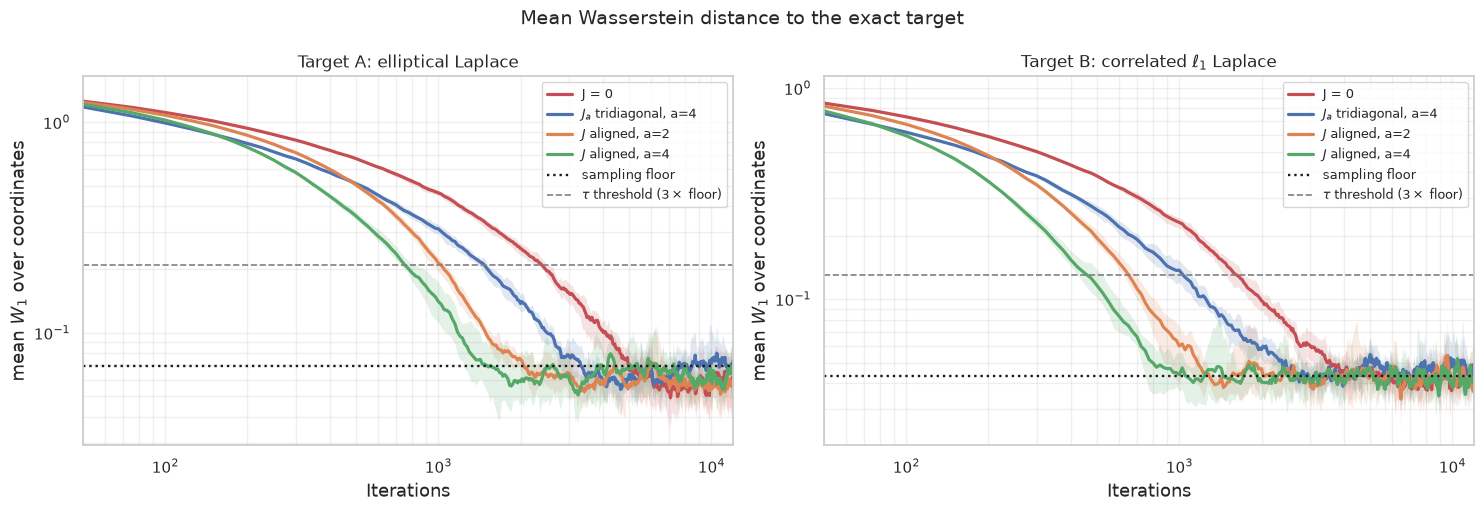

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, kind in zip(axes, TARGETS):
    for lab in MAIN:
        r = RES[kind][lab]
        ax.plot(r["it"], r["W"].mean(axis=0), linewidth=2.3, color=COL[lab], label=lab)
        ax.fill_between(r["it"], np.percentile(r["W"], 5, axis=0),
                        np.percentile(r["W"], 95, axis=0), color=COL[lab], alpha=0.16, linewidth=0)
    fl = floors[kind].mean()
    ax.axhline(fl, color="k", linestyle=":", linewidth=1.7, label="sampling floor")
    ax.axhline(TAU_MULT * fl, color="0.5", linestyle="--", linewidth=1.2,
               label=r"$\tau$ threshold ($3\times$ floor)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(50, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$ over coordinates", fontsize=13)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)
fig.suptitle("Mean Wasserstein distance to the exact target", fontsize=14)
plt.tight_layout()
plt.savefig("figures/mv_w1_mean.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 2 — component-wise

The same runs, split by coordinate. The mean above is dominated by coordinate 3, which has four times the
variance of coordinate 1 and mixes slowest; the per-coordinate view shows where the skew is actually
buying anything.

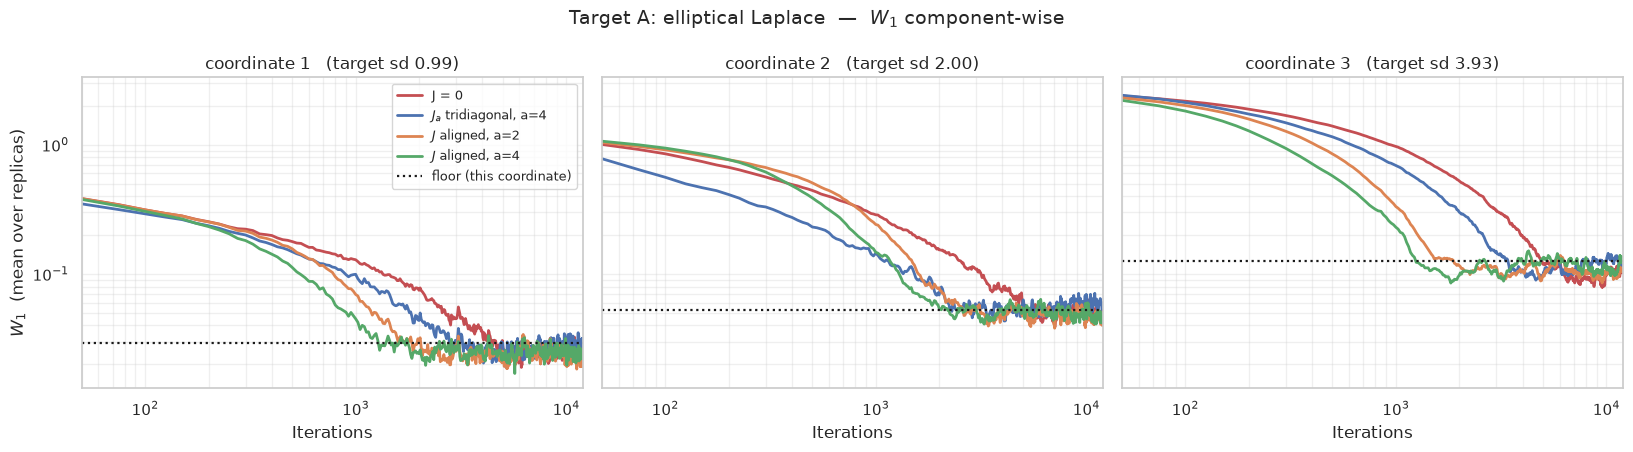

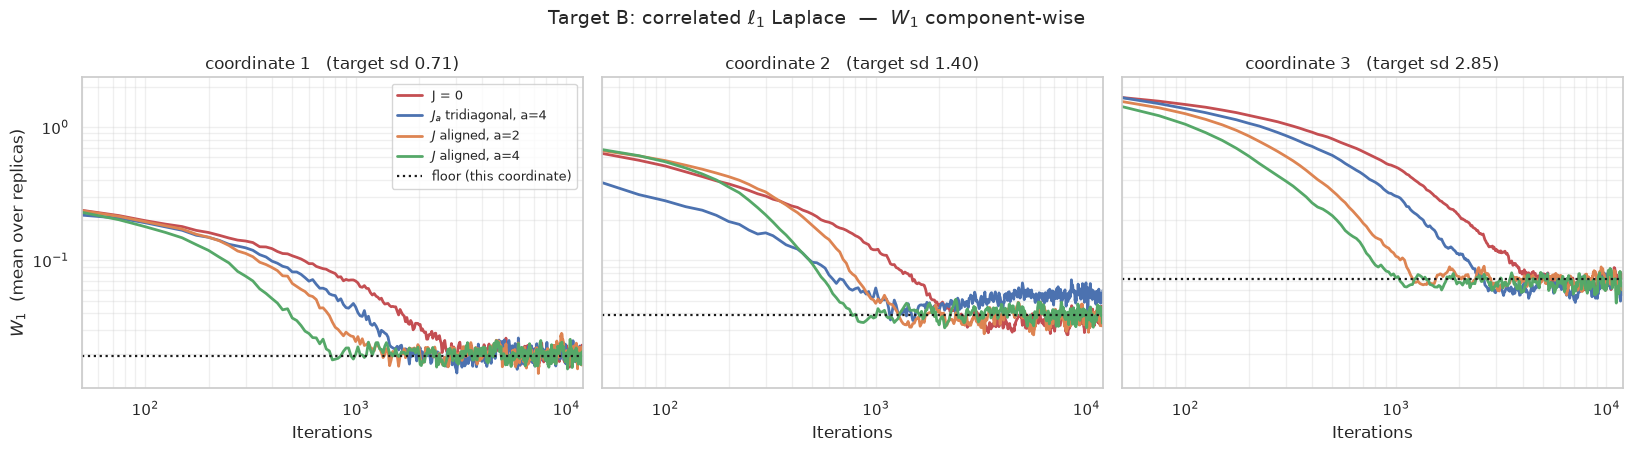

In [7]:
for kind in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6), sharey=True)
    for i, ax in enumerate(axes):
        for lab in MAIN:
            r = RES[kind][lab]
            ax.plot(r["it"], r["Wc"][:, i], linewidth=2, color=COL[lab], label=lab)
        ax.axhline(floors[kind][i], color="k", linestyle=":", linewidth=1.6,
                   label="floor (this coordinate)")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(50, MAXIT)
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_title("coordinate {}   (target sd {:.2f})".format(i + 1, refs[kind][:, i].std()),
                     fontsize=12)
        ax.grid(alpha=0.3, which="both")
    axes[0].set_ylabel(r"$W_1$  (mean over replicas)", fontsize=12)
    axes[0].legend(fontsize=9)
    fig.suptitle(TARGETS[kind] + r"  —  $W_1$ component-wise", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/mv_w1_percoord_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — aiming the rotation

In [8]:
rows = []
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    for lab in ["$J$ aligned, a=4", "$J_a$ tridiagonal, a=4", "$J$ anti-aligned, a=4"]:
        r = RES[kind][lab]
        rows.append({"target": kind, "skew at a = 4": lab.replace("$", "").split(",")[0],
                     "tau": fmt_tau(boot(r["taus"])),
                     "speed-up vs J = 0": fmt_speed(boot_speedup(base, r["taus"])),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*boot(r["stat"])),
                     "floor": round(floors[kind].mean(), 4)})
display(pd.DataFrame(rows).set_index(["target", "skew at a = 4"]))
print("Same strength, same invariant law -- only the rotation plane differs.")

tau   speed-up vs J = 0  \
target skew at a = 4                                            
ell    J aligned           775 [746, 808]  3.18x [3.02, 3.34]   
       J_a tridiagonal  1479 [1438, 1521]  1.66x [1.59, 1.74]   
       J anti-aligned   2229 [2100, 2362]  1.10x [1.03, 1.19]   
l1     J aligned           479 [446, 517]  3.41x [3.12, 3.73]   
       J_a tridiagonal   1033 [967, 1096]  1.58x [1.46, 1.72]   
       J anti-aligned   1475 [1412, 1533]  1.11x [1.04, 1.18]   

                                  stationary W1   floor  
target skew at a = 4                                     
ell    J aligned        0.0673 [0.0584, 0.0753]  0.0696  
       J_a tridiagonal  0.0688 [0.0595, 0.0766]  0.0696  
       J anti-aligned   0.0705 [0.0568, 0.0842]  0.0696  
l1     J aligned        0.0430 [0.0412, 0.0447]  0.0434  
       J_a tridiagonal  0.0440 [0.0413, 0.0474]  0.0434  
       J anti-aligned   0.0527 [0.0491, 0.0562]  0.0434

Same strength, same invariant law -- only the rotation plane differs.


## Experiment 4 — strength, and the stepsize it needs

$a$ cannot be raised indefinitely at fixed $\eta$: the drift is $(I+aJ)\nabla U_0$, so its magnitude grows
with $a$ and the Euler step eventually stops resolving it. The speed-up and the stationary error have to be
read together.

In [9]:
rows = []
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    fl = floors[kind].mean()
    for lab, _ in GRID:
        r = RES[kind][lab]
        st = boot(r["stat"])
        rows.append({"target": kind, "scheme": lab.replace("$", ""),
                     "tau": fmt_tau(boot(r["taus"])),
                     "speed-up": "--" if lab == "J = 0" else fmt_speed(boot_speedup(base, r["taus"])),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*st),
                     "vs floor": "{:.2f}x".format(st[0] / fl),
                     "tau resolvable": "yes" if tau_is_resolvable(st[0], fl) else "NO"})
display(pd.DataFrame(rows).set_index(["target", "scheme"]))
print("floor: " + ", ".join("{} {:.4f}".format(k, floors[k].mean()) for k in TARGETS))

tau            speed-up  \
target scheme                                                        
ell    J = 0                 2462 [2388, 2550]                  --   
       J_a tridiagonal, a=4  1479 [1438, 1521]  1.66x [1.59, 1.74]   
       J_a tridiagonal, a=8  1333 [1262, 1408]  1.85x [1.73, 1.97]   
       J aligned, a=2        1033 [1000, 1067]  2.38x [2.28, 2.50]   
       J aligned, a=4           775 [746, 808]  3.18x [3.02, 3.34]   
       J aligned, a=8           667 [654, 683]  3.69x [3.55, 3.85]   
       J anti-aligned, a=4   2229 [2100, 2362]  1.10x [1.03, 1.19]   
l1     J = 0                 1633 [1550, 1712]                  --   
       J_a tridiagonal, a=4   1033 [967, 1096]  1.58x [1.46, 1.72]   
       J_a tridiagonal, a=8   2596 [958, 5767]  0.63x [0.28, 1.73]   
       J aligned, a=2           662 [642, 683]  2.47x [2.32, 2.61]   
       J aligned, a=4           479 [446, 517]  3.41x [3.12, 3.73]   
       J aligned, a=8           358 [350, 367]  4.56x [4.28, 4.82]   
       J anti-aligned, a=4   1475 [1412, 1533]  1.11x [1.04, 1.18]   

                                       stationary W1 vs floor tau resolvable  
target scheme                                                                 
ell    J = 0                 0.0590 [0.0476, 0.0721]    0.85x            yes  
       J_a tridiagonal, a=4  0.0688 [0.0595, 0.0766]    0.99x            yes  
       J_a tridiagonal, a=8  0.1133 [0.1031, 0.1248]    1.63x            yes  
       J aligned, a=2        0.0578 [0.0500, 0.0672]    0.83x            yes  
       J aligned, a=4        0.0673 [0.0584, 0.0753]    0.97x            yes  
       J aligned, a=8        0.0862 [0.0804, 0.0933]    1.24x            yes  
       J anti-aligned, a=4   0.0705 [0.0568, 0.0842]    1.01x            yes  
l1     J = 0                 0.0452 [0.0402, 0.0512]    1.04x            yes  
       J_a tridiagonal, a=4  0.0440 [0.0413, 0.0474]    1.01x            yes  
       J_a tridiagonal, a=8  0.0924 [0.0866, 0.0983]    2.13x             NO  
       J aligned, a=2        0.0394 [0.0366, 0.0417]    0.91x            yes  
       J aligned, a=4        0.0430 [0.0412, 0.0447]    0.99x            yes  
       J aligned, a=8        0.0465 [0.0441, 0.0497]    1.07x            yes  
       J anti-aligned, a=4   0.0527 [0.0491, 0.0562]    1.21x            yes

floor: ell 0.0696, l1 0.0434


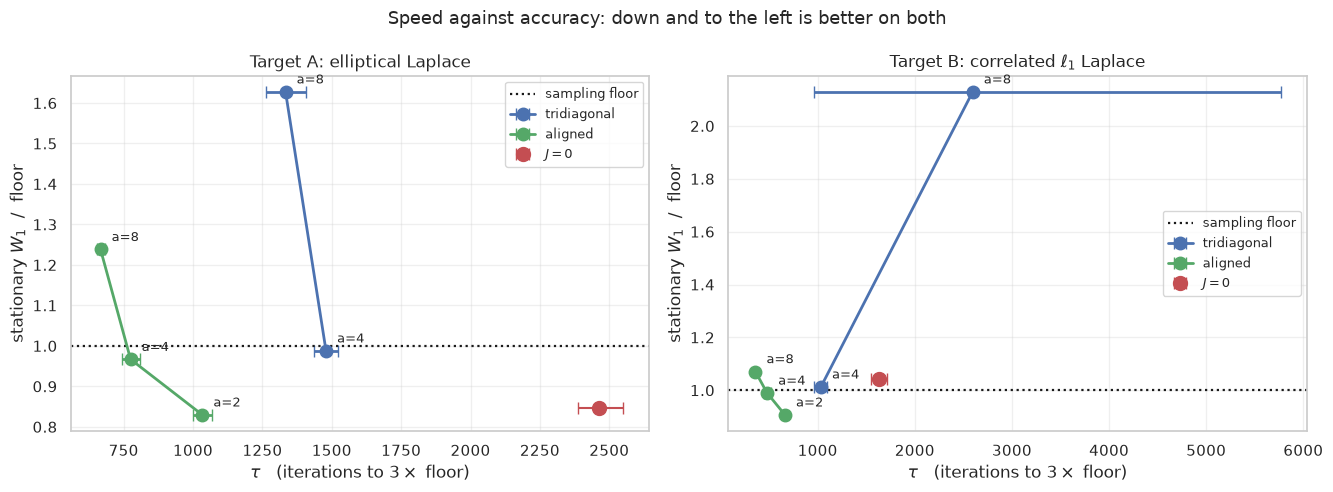

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, kind in zip(axes, TARGETS):
    base = RES[kind]["J = 0"]["taus"]
    fl = floors[kind].mean()
    for name, labs, c in [("tridiagonal", ["$J_a$ tridiagonal, a={:g}".format(a) for a in (4.0, 8.0)], "#4C72B0"),
                          ("aligned", ["$J$ aligned, a={:g}".format(a) for a in A_LIST], "#55A868")]:
        xs_ = [float(l.split("a=")[1]) for l in labs]
        tm = [boot(RES[kind][l]["taus"]) for l in labs]
        st = [boot(RES[kind][l]["stat"])[0] / fl for l in labs]
        ok = [i for i, v in enumerate(tm) if np.isfinite(v[0])]
        ax.errorbar([tm[i][0] for i in ok], [st[i] for i in ok],
                    xerr=[[tm[i][0] - tm[i][1] for i in ok], [tm[i][2] - tm[i][0] for i in ok]],
                    fmt="o-", color=c, capsize=4, linewidth=2, markersize=9, label=name)
        for i in ok:
            ax.annotate("a={:g}".format(xs_[i]), (tm[i][0], st[i]),
                        textcoords="offset points", xytext=(8, 6), fontsize=9)
        for i, v in enumerate(tm):
            if not np.isfinite(v[0]):
                ax.annotate("a={:g} never converges".format(xs_[i]), (0.03, 0.90 - 0.07 * i),
                            xycoords="axes fraction", fontsize=9, color=c)
    j0 = boot(RES[kind]["J = 0"]["taus"])
    ax.errorbar([j0[0]], [boot(RES[kind]["J = 0"]["stat"])[0] / fl],
                xerr=[[j0[0] - j0[1]], [j0[2] - j0[0]]], fmt="o", color="#C44E52",
                capsize=4, markersize=10, label="$J = 0$")
    ax.axhline(1.0, color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xlabel(r"$\tau$   (iterations to $3\times$ floor)", fontsize=12)
    ax.set_ylabel(r"stationary $W_1$  /  floor", fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle("Speed against accuracy: down and to the left is better on both", fontsize=13)
plt.tight_layout()
plt.savefig("figures/mv_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()

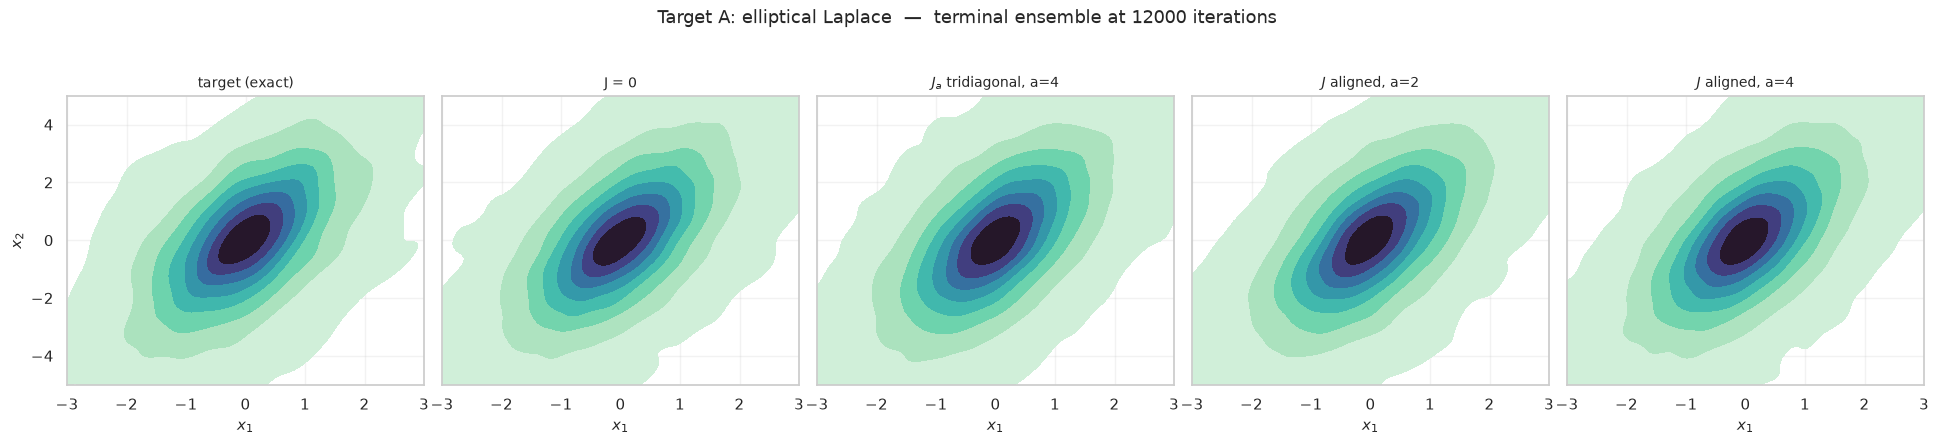

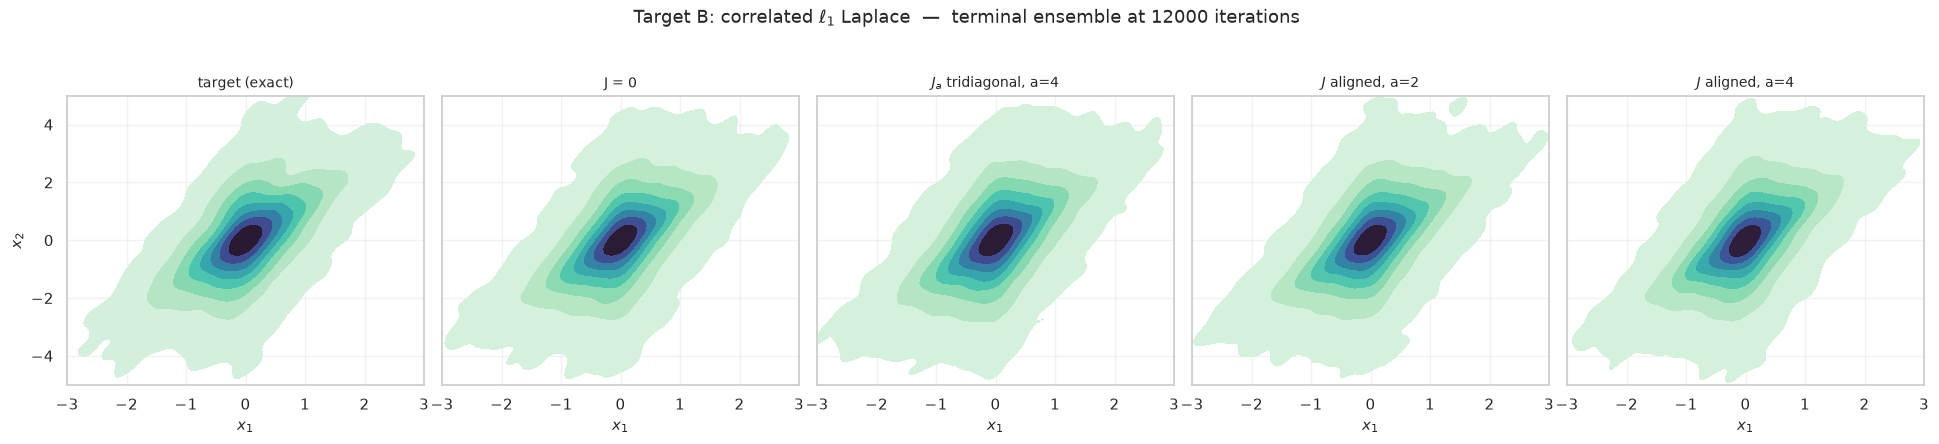

In [11]:
# terminal densities, dims 1 and 2
for kind in TARGETS:
    panels = [("target (exact)", refs[kind])] + [
        (lab, RES[kind][lab]["X"].reshape(-1, d)) for lab in MAIN]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.9 * len(panels), 4.3),
                             sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=9, ax=ax, thresh=0.02, cmap="mako_r")
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("$x_1$", fontsize=11)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-5, 5)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("$x_2$", fontsize=11)
    fig.suptitle(TARGETS[kind] + "  —  terminal ensemble at {} iterations".format(MAXIT),
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig("figures/mv_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Summary

Unconstrained, every constant antisymmetric $J$ leaves $\pi$ invariant, so the choice of $J$ is purely a
rate choice. The original notebook made that choice arbitrarily — a tridiagonal pattern with no relation
to $\Sigma$ — and read the result at a horizon where nothing had converged. Both are fixed here, and the
gain roughly doubles.

### Mean Wasserstein

| target | scheme | $\tau$ | speed-up | stationary $W_1$ | vs floor |
|---|---|---|---|---|---|
| **A** | $J=0$ | 2462 [2388, 2550] | — | 0.0590 | 0.85× |
| A | $J_a$ tridiagonal, $a=4$ | 1479 [1438, 1521] | 1.66× [1.59, 1.74] | 0.0688 | 0.99× |
| A | $J_a$ tridiagonal, $a=8$ | 1333 [1262, 1408] | 1.85× [1.73, 1.97] | 0.1133 | 1.63× |
| A | $J$ aligned, $a=2$ | 1033 [1000, 1067] | 2.38× [2.28, 2.50] | 0.0578 | 0.83× |
| A | $J$ aligned, $a=4$ | 775 [746, 808] | 3.18× [3.02, 3.34] | 0.0673 | 0.97× |
| A | $J$ aligned, $a=8$ | 667 [654, 683] | **3.69× [3.55, 3.85]** | 0.0862 | 1.24× |
| A | $J$ anti-aligned, $a=4$ | 2229 [2100, 2362] | 1.10× [1.03, 1.19] | 0.0705 | 1.01× |
| **B** | $J=0$ | 1633 [1550, 1712] | — | 0.0452 | 1.04× |
| B | $J_a$ tridiagonal, $a=4$ | 1033 [967, 1096] | 1.58× [1.46, 1.72] | 0.0440 | 1.01× |
| B | $J_a$ tridiagonal, $a=8$ | 2596 [958, 5767] | *not resolvable* | 0.0924 | 2.13× |
| B | $J$ aligned, $a=2$ | 662 [642, 683] | 2.47× [2.32, 2.61] | 0.0394 | 0.91× |
| B | $J$ aligned, $a=4$ | 479 [446, 517] | 3.41× [3.12, 3.73] | 0.0430 | 0.99× |
| B | $J$ aligned, $a=8$ | 358 [350, 367] | **4.56× [4.28, 4.82]** | 0.0465 | 1.07× |
| B | $J$ anti-aligned, $a=4$ | 1475 [1412, 1533] | 1.11× [1.04, 1.18] | 0.0527 | 1.21× |

**Aiming is worth about a factor of two on top of the strength.** At the same $a=4$: aligned 3.18× and
3.41×, tridiagonal 1.66× and 1.58×, anti-aligned 1.10× and 1.11× — the last is nothing, on either target.
Same invariant law, same $\lVert J\rVert$, only the rotation plane differs.

**And aiming is what lets the strength be raised.** The aligned field improves monotonically to $a=8$
(3.69× and 4.56×), while the tridiagonal one stalls on A and becomes unmeasurable on B, where its
stationary $W_1$ is 2.13× the floor. A skew pointed in the wrong plane has to be pushed harder for the
same effect, and pushing it harder is what breaks the discretisation.

**At $a\le4$ the acceleration is free.** Aligned $a=2$ and $a=4$ sit at or below the floor on both targets
(0.83-0.99×), so 3.18× and 3.41× cost nothing measurable. Only $a=8$ starts to show a price (1.24× on A),
and $\eta$ would have to come down to spend it.

### Component-wise

The mean is dominated by coordinate 3, which has four times the variance of coordinate 1 and mixes
slowest — and that is where the aligned field does its work, because coordinate 3 is the direction the
rotation plane was chosen to contain. On coordinate 1 the schemes are nearly indistinguishable.

The per-coordinate view also catches something the mean hides: on Target B coordinate 2, the tridiagonal
field descends *fastest* early but then settles slightly **above** the floor, while the aligned runs sit on
it. Averaging over coordinates cancels that against its coordinate-3 deficit.

### A correction to the measurement itself

The first pass at this produced nonsense on Target B — every skew apparently *slower* than $J=0$, with
intervals like $\tau=3533$ [908, 6467]. The cause was the floor estimator, not the samplers.

The floor was estimated as $W_1$ between one fixed reference and a handful of fresh draws. That estimator
carries the particular reference's own deviation, and across independent estimates its spread is 15-20%
per coordinate — the mean over coordinates ranged over 1.9× on Target B (0.0329 to 0.0620). One low draw
put the $\tau$ threshold at $2\times0.0354=0.0708$, only 1.65× above the converged plateau of ~0.043, so
replica curves wandered back across it late in the run and the last-crossing statistic became a lottery.

Two changes fix it: draw **both** sides fresh for each of 24 pairs, which removes the conditioning and
brings the spread to a few percent; and put the $\tau$ threshold at $3\times$ the floor, clear of every
scheme's stationary noise. A guard now marks any row where a scheme's plateau is within 1.5× of the
threshold, so an unmeasurable $\tau$ is labelled rather than reported — it fires on exactly one row,
tridiagonal $a=8$ on Target B.

### Two things the original got wrong on its own terms

The prose said $\eta=5\times10^{-3}$ over 2000 iterations; the code ran $6\times10^{-3}$ for 1500. And at
1500 iterations $J=0$ sits at mean $W_1=0.33$ against a floor of 0.070 — five times above it and still
falling. Every reported number was a position in a race, not a stationary law. The settings now live in
one place and are printed, and the horizon is 12000, where $J=0$ genuinely reaches the floor.